# Internal migration → ITL2 net migration

Builds **net internal migration per ITL2 region per year** and saves it to `clean/migration_itl2.csv`.

- **Source:** ONS “Internal migration in England and Wales” tables — the `IM{year}-T1a` sheets (2023 LA boundaries), which give Inflow / Outflow / Net per local authority. Back-series 2012–2021 plus individual year files 2022–2025, all sitting in `raw/migration/`.
- **Method:** read every `IM{year}-T1a` sheet → apply the LA-code crosswalk → join the geography spine → sum inflow/outflow to ITL2 → net = in − out.
- **Coverage:** England & Wales only — Scottish / NI regions come out blank (expected).

Run the cells top to bottom. The only thing you might edit is `BASE` in the first code cell.

In [1]:
import re
from pathlib import Path
import pandas as pd

# --- the ONE thing to edit: your project root ---
BASE = Path("/Users/h.cantekin/Library/CloudStorage/OneDrive-LondonSchoolofEconomics/Desktop/regional-panel")

MIG_DIR   = BASE / "raw" / "migration"
SPINE     = BASE / "clean" / "geography_spine.csv"
CROSSWALK = BASE / "lib" / "la_code_crosswalk.csv"
OUT       = BASE / "clean" / "migration_itl2.csv"
LA_PREFIX = ("E06", "E07", "E08", "E09", "W06", "S12", "N09")   # local-authority code types

def find_header(raw):
    """Find the row index of the real header (the row containing 'LA code' and 'Inflow')."""
    for i in range(min(12, len(raw))):
        row = [str(x).strip().lower() if x is not None else "" for x in raw.iloc[i].tolist()]
        if any("la code" in c for c in row) and any(c == "inflow" for c in row):
            return i
    return None

## 1. Extract the LA-level in/out tables

Reads every `IM{year}-T1a` sheet across all workbooks in `raw/migration/`. If a downloaded file uses different sheet names, it prints that file's sheet list so we can adjust the parser.

In [2]:
books = sorted(MIG_DIR.glob("*.xlsx"))
if not books:
    raise SystemExit(f"No .xlsx files in {MIG_DIR}. Download the ONS internal migration tables there.")

frames = []
for book in books:
    xl = pd.ExcelFile(book)
    got = 0
    for sh in xl.sheet_names:
        m = re.fullmatch(r"IM(\d{4})-T1a", sh)
        if not m:
            continue
        got += 1
        year = int(m.group(1))
        raw = xl.parse(sh, header=None)
        hdr = find_header(raw)
        if hdr is None:
            print(f"  ! {book.name}[{sh}]: no header row found, skipped")
            continue
        df = xl.parse(sh, skiprows=hdr)
        df.columns = [str(c).strip() for c in df.columns]
        la = [c for c in df.columns if c.lower().replace(" ", "") == "lacode"][0]
        ic = [c for c in df.columns if c.lower() == "inflow"][0]
        oc = [c for c in df.columns if c.lower() == "outflow"][0]
        sub = (df[[la, ic, oc]]
               .rename(columns={la: "la_code", ic: "inflow", oc: "outflow"})
               .dropna(subset=["la_code"]))
        sub["la_code"] = sub["la_code"].astype(str).str.strip()
        sub = sub[sub.la_code.str[:3].isin(LA_PREFIX)].copy()
        for c in ("inflow", "outflow"):
            sub[c] = pd.to_numeric(sub[c], errors="coerce")
        sub["year"] = year
        frames.append(sub)
    if got == 0:
        print(f"  (no IM{{year}}-T1a sheet in {book.name}; its sheets: {xl.sheet_names[:8]}{' ...' if len(xl.sheet_names) > 8 else ''})")

mig = pd.concat(frames, ignore_index=True).drop_duplicates(["la_code", "year"])
years = sorted(mig.year.unique())
print(f"Extracted {len(mig)} LA-year rows | years {years[0]}-{years[-1]} ({len(years)}) | {mig.la_code.nunique()} LAs")
mig.head()

Extracted 3180 LA-year rows | years 2012-2021 (10) | 318 LAs


,la_code,inflow,outflow,year
0,E06000001,3832.0,3370.0,2021
1,E06000002,7782.0,8792.0,2021
2,E06000003,5477.0,5073.0,2021
3,E06000004,9125.0,8894.0,2021
4,E06000005,6523.0,4910.0,2021


## 2. Harmonise old LA codes to current

Some years use retired local-authority codes. The crosswalk (built from the ONS Code History Database) maps them onto the current codes used in the spine, so nothing drops out at the join.

In [3]:
if CROSSWALK.exists():
    xw = pd.read_csv(CROSSWALK, dtype=str)
    remap = dict(zip(xw.old_code, xw.new_code))
    n = mig.la_code.isin(remap).sum()
    mig["la_code"] = mig["la_code"].replace(remap)
    print(f"Crosswalk applied: {n} row(s) recoded to current LA codes")
else:
    print("No crosswalk found -- run build/build_crosswalk.py first.")

Crosswalk applied: 20 row(s) recoded to current LA codes


## 3. Join the geography spine

Attach each LA's ITL2 region. Any LA code that doesn't match the spine is reported (a handful of genuinely-absent codes is fine; a lot would signal a problem).

In [4]:
spine = pd.read_csv(SPINE)
merged = mig.merge(spine, on="la_code", how="left")

unmatched = sorted(merged.loc[merged.itl2_code.isna(), "la_code"].dropna().unique())
if unmatched:
    print(f"NOTE: {len(unmatched)} LA code(s) not in spine (dropped): "
          f"{unmatched[:10]}{' ...' if len(unmatched) > 10 else ''}")
else:
    print("All LA codes matched the spine.")

merged = merged.dropna(subset=["itl2_code"])
merged.head()

All LA codes matched the spine.


,la_code,inflow,outflow,year,itl2_code,itl2_name
0,E06000001,3832.0,3370.0,2021,TLC3,Tees Valley
1,E06000002,7782.0,8792.0,2021,TLC3,Tees Valley
2,E06000003,5477.0,5073.0,2021,TLC3,Tees Valley
3,E06000004,9125.0,8894.0,2021,TLC3,Tees Valley
4,E06000005,6523.0,4910.0,2021,TLC3,Tees Valley


## 4. Aggregate to ITL2 and save

Inflow and outflow are counts, so they **sum** to the region. Net = inflow − outflow (within-region moves cancel, so summing is correct).

In [5]:
agg = merged.groupby(["itl2_code", "itl2_name", "year"], as_index=False)[["inflow", "outflow"]].sum()
agg["net_migration"] = agg["inflow"] - agg["outflow"]
agg = agg.sort_values(["year", "itl2_code"]).reset_index(drop=True)

OUT.parent.mkdir(parents=True, exist_ok=True)
agg.to_csv(OUT, index=False)
print(f"Saved -> {OUT}")
agg.head()

Saved -> /Users/h.cantekin/Library/CloudStorage/OneDrive-LondonSchoolofEconomics/Desktop/regional-panel/clean/migration_itl2.csv


,itl2_code,itl2_name,year,inflow,outflow,net_migration
0,TLC3,Tees Valley,2012,24926.0,27217.0,-2291.0
1,TLC4,"Northumberland, Durham and Tyne & Wear",2012,75945.0,77303.0,-1358.0
2,TLD1,Cumbria,2012,14532.0,15207.0,-675.0
3,TLD3,Greater Manchester,2012,124545.0,130799.0,-6254.0
4,TLD4,Lancashire,2012,78145.0,80918.0,-2773.0


## 5. Coverage check

Confirms how many of the 46 ITL2 regions have data. The blanks should be exactly the Scottish and NI regions (England & Wales source).

In [6]:
regions = spine[["itl2_code", "itl2_name"]].drop_duplicates()
covered = set(agg.itl2_code.unique())
missing = regions[~regions.itl2_code.isin(covered)]

print(f"Built ITL2 net migration: {len(covered)} of {len(regions)} regions x {len(years)} years")
if len(missing):
    print(f"Regions with NO data (expected -- England & Wales source only): {len(missing)}")
    print("  " + ", ".join(missing.itl2_name.tolist()))

Built ITL2 net migration: 39 of 46 regions x 10 years
Regions with NO data (expected -- England & Wales source only): 7
  Eastern Scotland, East Central Scotland, Highlands and Islands, West Central Scotland, North Eastern Scotland, Southern Scotland, Northern Ireland


## 6. (Optional) Temporal-consistency eyeball

ONS changed its migration method from mid-2023, so watch the **2022→2023** step for an artificial jump. This plots net migration over time for a few regions — a smooth line is good; a sudden break at 2023 is likely the method change, not real behaviour. (Needs `matplotlib`; skip if not installed.)

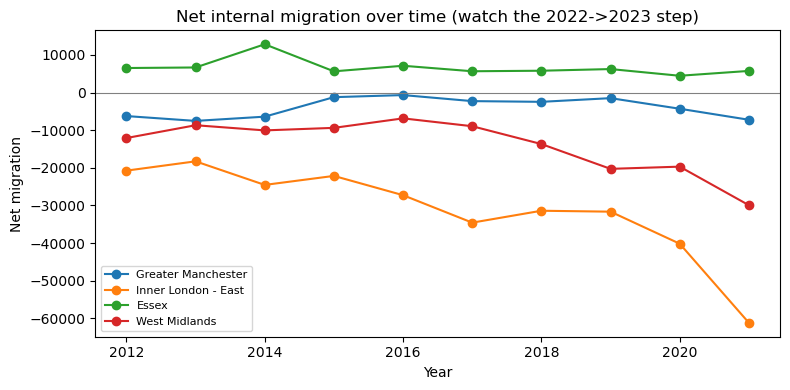

In [7]:
import matplotlib.pyplot as plt

sample = ["TLD3", "TLI4", "TLH3", "TLG3"]  # Greater Manchester, Inner London West, Essex, West Midlands
fig, ax = plt.subplots(figsize=(8, 4))
for code in sample:
    d = agg[agg.itl2_code == code]
    if len(d):
        ax.plot(d.year, d.net_migration, marker="o", label=d.itl2_name.iloc[0])
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("Net internal migration over time (watch the 2022->2023 step)")
ax.set_xlabel("Year"); ax.set_ylabel("Net migration")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()